In [ ]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
  from brentscheme import *
import numpy as np
import torch
from tqdm import trange
import pandas as pd
import time
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
scheme = BrentScheme(n=3, d=2, m=4, p=8, verbose=1)
factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

A scheme for (3 x 2) @ (2 x 4) using 8 products: complexity is n^1.963


In [ ]:
# @title File Save/Read Functions

# printer.test(scheme, verbose=0)
# round = lambda x,y:x # needed if dump_to_file throws an error - remember to use number= to avoid a long file name

# Save the scheme to Colab
# manipulator.set_norm(scheme, 2)
# score = printer.dump_to_file(scheme, number = -3.145)
# print(f"Score: {score}")

# Download the file from Colab to your computer. Remember to specify which scheme you want!
# download_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

# Read into locals() a scheme from Colab's files. Remember to specify which scheme you want!
# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=22)
# factory.read_from_files(scheme, n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=-3.130, verbose=2)

# Delete a scheme from Colab. Remember to specify which scheme you want!
# delete_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

The dimention of the tangent vector space to the following exact solution manifolds:
* Inner Products ($\alpha = (\beta \times \gamma)^{-1}$) ---> $p \cdot (d+1)$ ---> $p=d$:
  * 1,2,1,2: 6 of 10
  * 1,3,1,3: 12 of 21
  * 1,4,1,4: 20 of 36
* Outer Products ($\gamma = (\alpha \times \beta)^{-1}$) ---> $p \cdot (n+m)$ ---> $p=nm$:
  * 2,1,2,4: 16 of 32
  * 2,1,3,6: 30 of 66
  * 3,1,3,9: 54 of 135
* Mat-Vec ($\alpha = (\beta \times \gamma)^{-1}$) ---> $p \cdot (n+d)$ ---> $p=ndm$:
  * 2,2,1,4: 16 of 32
  * 2,3,1,6: 30 of 66
  * 3,2,1,6: 30 of 66
  * 3,3,1,9: 54 of 135
  * 2,4,1,8: 48 of 112
  * 3,4,1,12: 84 of 228
  * 4,4,1,16: 128 of 384
* Naive $p \cdot (n+d+m-1)$ ---> $p=ndm$:
  * 2,2,2,8: 40 of 96 (5p; 12 from LMR) (32 on a random solution)
  * 3,3,3,27: 216 of 729 (8p; 27 from LMR)
  * 4,4,4,64: 704 of 3072 (11p; 48 from LMR)
* Strassen/Winograd: 2,2,2,7: 23 of 84 (is prime; 12 from LMR) ($2 \cdot 7 + 9$)
* Laderman: 3,3,3,23: 76 of 621 (a shelf up to 83; 27 from LMR, 17 from SAT paper by Heule) ($3 \cdot 23 + 7$)
* Strassen$^2$: 4,4,4,49: 251 of 2352 (251 is prime; 48 from LMR) ($4 \cdot 49 + 55$)


# Prooving Minimal Representation with Free Param Argument

In [ ]:
# use the dot product case to see how we can deduce the basis of a random scheme
# TRY THE SAME WITH AN OUTER PRODUCT: p <= n*m, with d=1
# simplifies the terms somewhat, but they were mixed. A naive scheme with standard basis change is a repeated array, but a random scheme seems to have extra degrees of freedom.
# gets the first term to (1 x 1), every nth term to (1 x dm), and the first m terms to (nd x 1)

seed = 1
torch.random.manual_seed(seed)
np.random.seed(seed)

# get a random outer product scheme
factory.set_scheme(scheme, 'random', n=1, d=4, m=1, p=4) # inner product. Trivial. alpha or beta entirely determined by exactly the other two, exactly by an inverse.
factory.set_scheme(scheme, 'random', n=2, d=1, m=2, p=4) # outer product. Indicates that there is another kind of change of basis that affects some products.
factory.set_scheme(scheme, 'random', n=3, d=1, m=3, p=9) # outer product. Indicates that there is another kind of change of basis that affects some products.
# factory.set_scheme(scheme, 'random', n=3, d=1, m=2, p=6) # outer product. Indicates that there is another kind of change of basis that affects some products.
# factory.set_scheme(scheme, 'random', n=2, d=2, m=1, p=4) # mat-vec product. NOT READY
manipulator.set_norm(scheme, np.inf)
for i in range(150):
  stepper.epoch_pseudoinverse(scheme, batch_size=20)
  manipulator.normalize(scheme)

# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=22)
# factory.read_from_files(scheme, n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=-3.110, verbose=1) # the goal


# factory.set_scheme(scheme, 'naive', n=2, d=2, m=1, p=4) # mat-vec product
# printer.report(scheme, verbose=2)
# manipulator.change_basis(scheme, L=rand_square(2), M=rand_square(2))

# default basis
new_L = torch.eye(scheme.n)
new_R = torch.eye(scheme.m)
new_M = torch.eye(scheme.d)

# fix it by using its own natural basis
if scheme.n == 1 and scheme.m == 1: # inner product
  new_M = scheme.beta__pdm[:scheme.d,:,0] # can equivalently use a pseudoinverse over selected entries of alpha
elif scheme.d == 1: # outer product
  # scheme.gamma_nmp = torch.linalg.pinv(torch.einsum("pnd,pdm->pnm", scheme.alpha_pnd, scheme.beta__pdm).reshape(scheme.p, -1)).reshape(scheme.n, scheme.m, scheme.p)
  new_L = torch.linalg.pinv(scheme.alpha_pnd[:scheme.n,:,0]) # instead of this pinv, what is the slice that gives us a basis without pinv? Use gamma?
  new_R = torch.linalg.pinv(scheme.beta__pdm[:scheme.m,0,:]).T
elif scheme.m == 1: # mat-vec product
  new_L = torch.linalg.pinv(scheme.alpha_pnd[:scheme.n**2:scheme.n,:,0]) # just this, some entries of alpha to zero
  new_M = scheme.beta__pdm[:scheme.d,:,0] # just this, some entries of beta to zero
else: # not yet implemented
  print("NOT YET IMPLEMENTED **************************************************************************************************************")

printer.report(scheme, verbose=2)
manipulator.change_basis(scheme, L=new_L, M=new_M, R=new_R)
if scheme.n == 1 and scheme.m == 1:
  manipulator.normalize(scheme)
# manipulator.normalize(scheme)
manipulator.round(scheme, 13)
printer.report(scheme, verbose=2)

Scheme for (3×1) @ (1×3) using p=9 out of 9 products; complexity n^3.000
Norm: Linf over field None
Avg L1 error: 10^-14.9319, Avg L2 error: 10^-14.8053, Max error: 10^-14.3525

Products P_i = (alpha_i · A) * (beta_i · B)
P_1 = ( 2.177*A[1,1] +  1.023*A[2,1] + -1.637*A[3,1]) * (-2.177*B[1,1] + -0.525*B[1,2] +  0.224*B[1,3])
P_2 = ( 0.407*A[1,1] +  1.086*A[2,1] +  1.934*A[3,1]) * (-0.876*B[1,1] + -1.934*B[1,2] +  0.338*B[1,3])
P_3 = ( 1.539*A[1,1] +  1.934*A[2,1] +  0.187*A[3,1]) * ( 1.934*B[1,1] +  1.599*B[1,2] + -0.559*B[1,3])
P_4 = ( 1.663*A[1,1] +  0.245*A[2,1] + -1.742*A[3,1]) * (-1.742*B[1,1] +  0.959*B[1,2] +  0.385*B[1,3])
P_5 = ( 1.505*A[1,1] +  0.314*A[2,1] + -0.800*A[3,1]) * (-1.177*B[1,1] +  0.231*B[1,2] +  1.505*B[1,3])
P_6 = ( 1.424*A[1,1] + -0.581*A[2,1] + -0.931*A[3,1]) * ( 1.424*B[1,1] + -0.580*B[1,2] + -0.620*B[1,3])
P_7 = ( 1.321*A[1,1] + -0.429*A[2,1] +  0.949*A[3,1]) * ( 0.064*B[1,1] + -1.321*B[1,2] +  0.387*B[1,3])
P_8 = ( 0.852*A[1,1] +  0.663*A[2,1] + -0.960*A[3,

There will always be more p than n or m i.e. as $nm \le p \le ndm$, $p \ge \max(n,m)$

Furthermore, if $p \ge \max(nd,md)$, and we flatten alpha and beta into $\alpha_{pa},\beta_{pb}$, then we guarantee that for the row vectors of these matrices (row vectors in $\mathbb{R}^a, \mathbb{R}^b$), there will be $p$ of each, so they will necesarily be linearly dependent. Assume that any square block of rows span their respective vector space (as these vectors are essentially random) (does the fact that these vectors are outer products change this? Can we prove that product vectors are independent iff their factors were independent?).

We unfortunaly cannot choose a basis that makes these vestors align, unless they alrady are aligned, as the change of basis preserves parallel lines.

In the outer product case $(d=1)$, we have exactly a change of basis $L,R$ for alpha and beta across $a,b$ respectively. We now have $m$ complete bases for the rows of alpha and $n$ complete bases for the rows of beta. We can thus choose a basis $L,R$ which simplifies (eliminates) $\min(n,m)$ products to a single-term case, with $|n-m|$ products having just one side down to one term (the larger of $n,m$).

Now the diagonal of the product matrix $C_{ii}$ is taken care of. We know that these were involved in many identities from the alpha*beta product tensor (the inverse of gamma). These all have the form $\alpha\beta_{iab}*\alpha\beta_{iAB}=\alpha\beta_{iaB}*\alpha\beta_{iAb}$. These identities impose three types of constraints on $\alpha\beta$: either the fourth of these parameters is determined by the other three nonzero entries, or must be zero given a zero on the other side and a nonzero partner, or can be arbitrary in the same situation given a zero partner.

In [ ]:
# For an outer product (2x2), parametrize the first-reduced scheme
# TODO: Find the inverse transform, generalize to (n x 1) x (1 x m)

# factory.set_scheme(scheme, 'naive', n=3, d=1, m=3, p=9) # outer product. Indicates that there is another kind of change of basis that affects some products.
# factory.set_scheme(scheme, 'naive', n=2, d=1, m=2, p=4) # outer product. Indicates that there is another kind of change of basis that affects some products.

# where the paramters come from
_orig = torch.linalg.pinv(scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,1:]) # always correct
print(torch.linalg.pinv(_orig).round(decimals=4))
print(_orig.round(decimals=4))



### Code Specific to 2x3 ###
if scheme.n == 2 and scheme.m == 3:
  params = np.random.randn(15)*2 -1
  # params[32:36] = scheme.alpha_pnd[(4,5,7,8),1,0] # use to retain original scale

  # use to generate a new scheme
  #                      12          13            21          22          23
  _orig = torch.tensor([[params[0],  0.0000,       0.0000,     params[1],  0.0000,  ],  # every nth entry, starting at row number ########## KEPT FROM 3x3
                        [0.0000,     params[2],    0.0000,     0.0000,     params[3]],  # OR n diagonal matrices with row/col 1 cut out ########## KEPT FROM 3x3

                        [0.0000,     0.0000,       params[4],  params[5],  params[6]], # second block of n ########## KEPT FROM 3x3
                        [params[7],  params[8],    params[9],  params[10], -1       ], # solid ########## KEPT FROM 3x3
                        [params[11], params[12],   params[13], params[14], -1       ]]) # solid ########## KEPT FROM 3x3

  # the following are identities
  # _orig[(3,4,6,7),4] = _orig[(3,4,6,7),1] * _orig[(3,4,6,7),3] / _orig[(3,4,6,7),0] # coeffs on 12 * 23 = 13 * 22
  # _orig[(3,4,6,7),6] = _orig[(3,4,6,7),3] * _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # coeffs on 22 * 31 = 21 * 32
  # _orig[(3,4,6,7),7] = _orig[(3,4,6,7),4] * _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # coeffs on 23 * 31 = 21 * 33
  # assert torch.allclose(_orig[(3,4,6,7),7], _orig[(3,4,6,7),1] * _orig[(3,4,6,7),6] / _orig[(3,4,6,7),0]) # coeffs on 32 * 13 = 12 * 33 (derived from the other two)

  # use the parameters to change the scheme

  # P_1,P_3 are 1 x 1 (trivial, =1)
  # does this mean we eliminate that column as well?

  # P_2 is 3 x 1
  for j in range(scheme.n):
    for i in range(scheme.m-1):
      # scheme.alpha_pnd[i+1,j,0] =
      print(_orig[i,scheme.m*j+i])

  # none are 1 x 3

  # P_4, P_5, P_6, are 3 x 3
  # scheme.alpha_pnd[(4,5,7,8),0,0] = _orig[(3,4,6,7),0] / _orig[(3,4,6,7),3]
  # scheme.alpha_pnd[(4,5,7,8),1,0] =  1 # make _a2 * _b1 = _orig[3,2]
  # scheme.alpha_pnd[(4,5,7,8),2,0] = _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # make _a3 * _b1 = _orig[3,5]
  # scheme.beta__pdm[(4,5,7,8),0,0] = _orig[(3,4,6,7),2] # make _a1 * _b1 = _g5 below
  # scheme.beta__pdm[(4,5,7,8),0,1] = _orig[(3,4,6,7),3] # make _a1 * _b2 = _orig[3,0]
  # scheme.beta__pdm[(4,5,7,8),0,2] = _orig[(3,4,6,7),4] # make _a1 * _b3 = _orig[3,1] ==? _orig[3,4]

  # Gamma TL entry is 1 x 1 (trivial, =1)

  # Gamma TR row vector is all zeros

  # Gamma BR block is inverse of basis
  # scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,1:] =
  print(torch.linalg.pinv(_orig)) # BR block of gamma: always correct

  # Gamma BL column vector is made to eliminiate first entry from other products in the BR block
  # i.e. get coeffs for 11
  # _11_filter = torch.zeros(scheme.p-1, dtype=torch.float64)
  # for i in (3,4,6,7):
  #   _11_filter[i] = _orig[i,0] * _orig[i,2] / _orig[i,3] # coeffs for 11 = 12 * 21 / 22 (indices in product matrix). can also do any others (1j * i1 / ij)
  # scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,0] =
  # print(-torch.linalg.pinv(_orig) @ _11_filter) # columns from solid rows

  # only needed to recover exact values
  # scales = torch.ones(scheme.p, dtype=torch.float64)
  # scales[(4,5,7,8),] = torch.from_numpy(params[-4:])
  # manipulator.scale_products(scheme, scales, 1/scales)







### Code Specific to 3x3 ###
if scheme.n == 3 and scheme.m == 3:
  params = np.random.randn(36)*2 -1
  params[32:36] = scheme.alpha_pnd[(4,5,7,8),1,0] # use to retain original scale

  # use to generate a new scheme
  #                      12          13            21          22          23            31          32          33
  # _orig = torch.tensor([[params[0],  0.0000,       0.0000,     params[1],  0.0000,       0.0000,     params[2],  0.0000    ],  # every nth entry, starting at row number ########## KEEP THIS TO 2
  #                       [0.0000,     params[3],    0.0000,     0.0000,     params[4],    0.0000,     0.0000,     params[5] ],  # OR n diagonal matrices with row/col 1 cut out

  #                       [0.0000,     0.0000,       params[6],  params[7],  params[8],    0.0000,     0.0000,     0.0000    ], # second block of n  ########## KEEP THIS TO 2
  #                       [params[9],  params[10],   params[11], params[12], -1,           params[13], -1,         -1        ], # solid ########## KEEP THIS TO 2 ????
  #                       [params[14], params[15],   params[16], params[17], -1,           params[18], -1,         -1        ], # solid

  #                       [0.0000,     0.0000,       0.0000,     0.0000,     0.0000,       params[19], params[20], params[21]], # last block of n
  #                       [params[22], params[23],   params[24], params[25], -1,           params[26], -1,         -1        ], # solid
  #                       [params[27], params[28],   params[29], params[30], -1,           params[31], -1,         -1        ]])# solid

  # # the following are identities
  # _orig[(3,4,6,7),4] = _orig[(3,4,6,7),1] * _orig[(3,4,6,7),3] / _orig[(3,4,6,7),0] # coeffs on 12 * 23 = 13 * 22
  # _orig[(3,4,6,7),6] = _orig[(3,4,6,7),3] * _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # coeffs on 22 * 31 = 21 * 32
  # _orig[(3,4,6,7),7] = _orig[(3,4,6,7),4] * _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # coeffs on 23 * 31 = 21 * 33
  # assert torch.allclose(_orig[(3,4,6,7),7], _orig[(3,4,6,7),1] * _orig[(3,4,6,7),6] / _orig[(3,4,6,7),0]) # coeffs on 32 * 13 = 12 * 33 (derived from the other two)

  # use the parameters to change the scheme

  # P_1 is 1 x 1 (trivial, =1)

  # P_2,P_3 is 3 x 1
  for j in range(scheme.n):
    for i in range(scheme.m-1):
      scheme.alpha_pnd[i+1,j,0] = _orig[i,scheme.m*j+i]

  # P_4,P_7 is 1 x 3
  for i in (2,5):
    for j in range(scheme.m):
      scheme.beta__pdm[i+1,0,j] = _orig[i,j+i]

  # P_5, P_6, P_8, P_9 are 3 x 3
  scheme.alpha_pnd[(4,5,7,8),0,0] = _orig[(3,4,6,7),0] / _orig[(3,4,6,7),3]
  scheme.alpha_pnd[(4,5,7,8),1,0] =  1 # make _a2 * _b1 = _orig[3,2]
  scheme.alpha_pnd[(4,5,7,8),2,0] = _orig[(3,4,6,7),5] / _orig[(3,4,6,7),2] # make _a3 * _b1 = _orig[3,5]
  scheme.beta__pdm[(4,5,7,8),0,0] = _orig[(3,4,6,7),2] # make _a1 * _b1 = _g5 below
  scheme.beta__pdm[(4,5,7,8),0,1] = _orig[(3,4,6,7),3] # make _a1 * _b2 = _orig[3,0]
  scheme.beta__pdm[(4,5,7,8),0,2] = _orig[(3,4,6,7),4] # make _a1 * _b3 = _orig[3,1] ==? _orig[3,4]

  # Gamma TL entry is 1 x 1 (trivial, =1)

  # Gamma TR row vector is all zeros

  # Gamma BR block is inverse of basis
  scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,1:] = torch.linalg.pinv(_orig) # BR block of gamma: always correct

  # Gamma BL column vector is made to eliminiate first entry from other products in the BR block
  # i.e. get coeffs for 11
  _11_filter = torch.zeros(scheme.p-1, dtype=torch.float64)
  for i in (3,4,6,7):
    _11_filter[i] = _orig[i,0] * _orig[i,2] / _orig[i,3] # coeffs for 11 = 12 * 21 / 22 (indices in product matrix). can also do any others (1j * i1 / ij)
  scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,0] = -torch.linalg.pinv(_orig) @ _11_filter # columns from solid rows

  # only needed to recover exact values
  scales = torch.ones(scheme.p, dtype=torch.float64)
  scales[(4,5,7,8),] = torch.from_numpy(params[-4:])
  manipulator.scale_products(scheme, scales, 1/scales)







### Code Specific to 2x2 ###
if scheme.n == 2 and scheme.m == 2:
  params = np.random.randn(8)*2 -1
  params[-1:] = scheme.alpha_pnd[3,1,0].item() # .item() reduces the accuracy to 1e-7. Use to retain existing scale

  # use to generate a new scheme
  #                      12         21         22
  _orig = torch.tensor([[params[0], 0.0000,    params[1]], # top block - diags missing [1:,1:]
                        [0.0000,    params[2], params[3]], # second block solid
                        [params[4], params[5], params[6]]]) # bottom row in block solid

  # P_1 is 1 x 1 (trivial, =1)

  # P_2 is 2 x 1
  for j in range(scheme.n):
    for i in range(scheme.m-1):
      scheme.alpha_pnd[i+1,j,0] = _orig[i,scheme.m*j+i]

  # P_3 is 1 x 2
  for i in (1,):
    for j in range(scheme.m):
      scheme.beta__pdm[i+1,0,j] = _orig[i,i+j]

  # P_4 is 2 x 2 (exists a free parameter for alpha / beta magnitude ratio, use manipulator.scale_products)
  scheme.alpha_pnd[3,0,0] = _orig[2,0] / _orig[2,2]
  scheme.alpha_pnd[3,1,0] = 1 # can move factors from alpha to beta using scale_products for this one product
  scheme.beta__pdm[3,0,0] = _orig[2,1] # make _a1 * _b1 = _g4 below
  scheme.beta__pdm[3,0,1] = _orig[2,2] # make _a1 * _b2 = _orig[2,0]
  # assert torch.allclose(_orig[(2),4],  _orig[(2),1] * _orig[(2),3] / _orig[(2),0]), "P_5 identity failed"

  # Gamma TL entry is 1 x 1 (trivial, =1)

  # Gamma TR row vector is all zeros

  # Gamma BR block is inverse of basis
  scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,1:] = torch.linalg.pinv(_orig) # BR block of gamma: always correct

  # Gamma BL column vector is made to eliminiate first entry from other products in the BR block
  _11_filter = torch.zeros(scheme.p-1, dtype=torch.float64)
  for i in (2,):
    _11_filter[i] = _orig[i,0] * _orig[i,1] / _orig[i,2] # coeffs for 11 = 12 * 21 / 22 (indices in product matrix). can also do any others (1j * i1 / ij)
  scheme.gamma_nmp.reshape(scheme.n*scheme.m, scheme.p)[1:,0] = -torch.linalg.pinv(_orig) @ _11_filter # columns from solid rows

  # only needed to recover exact values
  scales = torch.ones(scheme.p, dtype=torch.float64)
  scales[(3),] = torch.from_numpy(params[-1:])
  manipulator.scale_products(scheme, scales, 1/scales)



printer.report(scheme, verbose=2)

tensor([[-4.4313, -4.5090,  2.2096, -4.0379, -3.8321,  3.3091,  2.1959,  0.3818],
        [ 3.1256,  3.1793, -1.6293,  2.6939,  2.6164, -2.3234, -1.6932, -0.2650],
        [ 8.2625,  7.6762, -6.9917,  7.1126,  5.6538, -5.7858, -2.7014, -1.2807],
        [ 1.0000, -0.0000,  0.0000, -0.0000, -0.0000,  0.0000,  0.0000,  0.0000],
        [-6.1810, -5.1228,  4.6790, -4.8274, -3.8066,  3.8710,  1.7942,  0.2741],
        [ 3.9566,  3.4323, -3.0636,  3.9228,  3.5320, -3.0000, -2.1022, -1.1143],
        [-4.1705, -5.1498,  3.2327, -4.1744, -3.7140,  3.1506,  1.6742,  0.3917],
        [ 0.0000,  1.0000, -0.0000,  0.0000,  0.0000, -0.0000, -0.0000, -0.0000]],
       dtype=torch.float64)
tensor([[ 0.0000,  0.0000,  0.0000,  1.0000,  0.0000, -0.0000, -0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0000,  0.0000,  0.0000,  0.0000, -0.0000,  1.0000],
        [-2.3761, -2.2680, -0.0132, -0.1794, -0.1712,  0.0798,  1.0853,  1.0359],
        [-5.8116, -8.3265, -2.4330, -3.1782, -4.5535,  3.0794,  4.022

/tmp/ipython-input-356706311.py:85: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  params[32:36] = scheme.alpha_pnd[(4,5,7,8),1,0] # use to retain original scale


It was here that I realized the learned minimizing tensor was just a pseudoinverse of the other two tensors' product.

# Tangent Vector Space to Solution Manifold

In [ ]:
# Find a Basis for the Tangent Space to Solution Manifold
# Usage: With enough sample points and batch sizes, we should see a clear plateau
# This indicates which directions we can move in the parameter space while maintaining the accuracy of the model
# For now, we have to manually inspect these directions to determine where the falloff is, how many smaples/iteration to use, etc.
def find_tangent_space(scheme, num_kept, noise_mag=1e-3, verbose=0):
  perterbs = []
  for i in trange(max(80, int(2.5*scheme.p*(scheme.n*scheme.d + scheme.d*scheme.m + scheme.n*scheme.m)))):
    working = scheme.clone()
    manipulator.add_noise(working, noise_mag)
    stepper.epoch_pseudoinverse(working, batch_size=80)
    perterbs.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))

  perterbs = torch.stack(perterbs)
  U, sigma, V_t = torch.linalg.svd(perterbs)
  if verbose > 0:
    ranks = torch.log10(sigma)
    significant = torch.where(ranks > np.log10(noise_mag))[0].max().item() + 1
    plt.title(f"{significant} Degrees of Freedom, out of {scheme.p*(scheme.n*scheme.d + scheme.d*scheme.m + scheme.n*scheme.m)}")
    plt.plot(ranks)
    plt.axvline(x=significant - 1, color='red', linestyle=':')
    plt.axhline(y=np.log10(noise_mag), color='red', linestyle=':')
    plt.show()

  return V_t[:num_kept,:]

In [ ]:
# Evaluate a function for each direction in a given tangent space
def get_perterbation_data(scheme, direction, eval_func, step_size):
  delta_alpha = direction[:scheme.n*scheme.d*scheme.p].reshape(scheme.p, scheme.n, scheme.d)
  delta_beta = direction[scheme.n*scheme.d*scheme.p:(scheme.n*scheme.d+scheme.n*scheme.m)*scheme.p].reshape(scheme.p, scheme.d, scheme.m)
  delta_gamma = direction[(scheme.n*scheme.d+scheme.d*scheme.m)*scheme.p:].reshape(scheme.n, scheme.m, scheme.p)
  scheme.alpha_pnd += delta_alpha * step_size
  scheme.beta__pdm += delta_beta * step_size
  scheme.gamma_nmp += delta_gamma * step_size
  if eval_func is None:
    return scheme
  change = eval_func(scheme)
  scheme.alpha_pnd -= delta_alpha * step_size
  scheme.beta__pdm -= delta_beta * step_size
  scheme.gamma_nmp -= delta_gamma * step_size
  return change

Scheme for (2×2) @ (2×2) using p=8 out of 8 products; complexity n^3.000
Norm: L1 over field R
Avg L1 error: 10^-inf, Avg L2 error: 10^-inf, Max error: 10^-inf


100%|██████████| 240/240 [00:14<00:00, 16.35it/s]


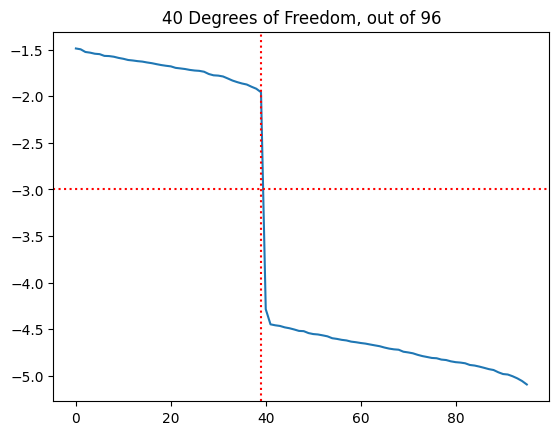


 torch.Size([40, 96])


In [ ]:
# take a solution (exact or approximate)
# add noise to it and train it
# flatten all parameters into a single vector
# concatonate those vectors, analyze dim(span(param_vects)) to find solution manifold dimention (use small noise to get a local sample in case the manifold is curved into a larger space)
# perhaps a PCA analysis will help detect which directions are actual degrees of freedom and which are just slight curvature of the manifold

torch.manual_seed(0)
np.random.seed(0)
factory.set_scheme(scheme, 'naive', n=2, d=2, m=2, p=8)
# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=22)
# factory.read_from_files(scheme, n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=-3.145, verbose=0)
# stepper.epoch_pseudoinverse(scheme, batch_size=4000)
# scheme = factory.compose_schemes(scheme,scheme)
printer.report(scheme, verbose=1)

basis = find_tangent_space(scheme, 40, noise_mag=1e-3, verbose=1)
print("\n", basis.size()) # known free parameters x total scheme parameters

torch.Size([28, 96])


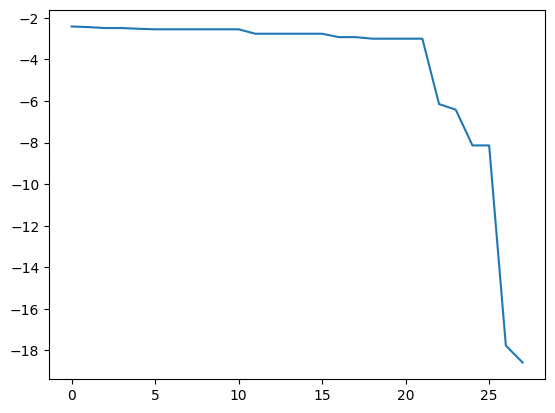

In [ ]:
# find a basis for perturbations made by LMR change of basis
# factory.set_scheme(scheme, 'naive', n=2, d=2, m=2)

changes = []
step_size = 1e-3
for i in range(scheme.n):
  for j in range(scheme.n):
    working = scheme.clone()
    perturbation = torch.eye(scheme.n)
    perturbation[i,j] += step_size
    manipulator.change_basis(working, L=perturbation)
    changes.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))

for i in range(scheme.d):
  for j in range(scheme.d):
    working = scheme.clone()
    perturbation = torch.eye(scheme.d)
    perturbation[i,j] += step_size
    manipulator.change_basis(working, M=perturbation)
    changes.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))

for i in range(scheme.m):
  for j in range(scheme.m):
    working = scheme.clone()
    perturbation = torch.eye(scheme.m)
    perturbation[i,j] += step_size
    manipulator.change_basis(working, R=perturbation)
    changes.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))

for i in range(scheme.p):
    working = scheme.clone()
    perturbation = [1.0]*scheme.p
    perturbation[i] += step_size
    manipulator.scale_products(working, perturbation, [1.0]*scheme.p)
    changes.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))
    working = scheme.clone()
    perturbation = [1.0]*scheme.p
    perturbation[i] += step_size
    manipulator.scale_products(working, [1.0]*scheme.p, perturbation)
    changes.append(torch.cat([(working.alpha_pnd - scheme.alpha_pnd).flatten(), (working.beta__pdm - scheme.beta__pdm).flatten(), (working.gamma_nmp - scheme.gamma_nmp).flatten()]))

changes = torch.stack(changes)
print(changes.size()) # known free parameters x total scheme parameters
U, sigma, V_t = torch.linalg.svd(changes)
plt.plot(torch.log10(sigma))

# Trying to Extend these results to $\min(n,d,m)=1$ Schemes

In [ ]:
# CONJECTURE: 2 x d x 2 schemes add 4 on odd, 3 on even (tiled Strassen)

scheme = BrentScheme(n=2, d=2, m=2, p=6) # solve for double inner product
manipulator.set_norm(scheme, np.inf)
# hypothesis: runtime is n*d*log(n) + d*m*log(m) + d*sqrt(n*m) instead of n*m*log(d)
printer.report(scheme, verbose=1)
stepper.epoch_pseudoinverse(scheme, batch_size=10)
stepper.optimize(scheme, batch_size=2, method=stepper.optimize_infinity_norm)
printer.plot_triple_deltas(scheme)